## Toy dataset (size=200)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
np.random.seed(42)

X = np.random.randn(200, 1)
y = 3 * X + 2 + np.random.randn(200, 1) * 0.5


In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)


In [ ]:
def init_params():
    return {
        "W1": np.random.randn(1, 10) * 0.1,
        "b1": np.zeros((1, 10)),
        "W2": np.random.randn(10, 1) * 0.1,
        "b2": np.zeros((1, 1))
    }


In [ ]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    return Z1, A1, Z2


MSE

In [ ]:
def loss(y, y_hat):
    return np.mean((y - y_hat) ** 2)


In [ ]:
def backward(X, y, Z1, A1, y_hat, params):
    m = X.shape[0]

    dZ2 = (y_hat - y) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


In [ ]:
def train(optimizer, epochs=100, lr=0.01):
    params = init_params()
    losses = []

    velocity = {k: np.zeros_like(v) for k, v in params.items()}
    cache = {k: np.zeros_like(v) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}

    for t in range(1, epochs + 1):
        Z1, A1, y_hat = forward(X, params)
        losses.append(loss(y, y_hat))

        grads = backward(X, y, Z1, A1, y_hat, params)

        if optimizer == "gd":
            params = gd_update(params, grads, lr)

        elif optimizer == "momentum":
            params, velocity = momentum_update(params, grads, velocity, lr)

        elif optimizer == "nag":
            params, velocity = nesterov_update(params, grads, velocity, lr)

        elif optimizer == "sgd":
            i = np.random.randint(0, len(X))
            Z1, A1, y_hat = forward(X[i:i+1], params)
            grads = backward(X[i:i+1], y[i:i+1], Z1, A1, y_hat, params)
            params = sgd_update(params, grads, lr)

        elif optimizer == "adagrad":
            params, cache = adagrad_update(params, grads, cache, lr)

        elif optimizer == "rmsprop":
            params, cache = rmsprop_update(params, grads, cache, lr)

        elif optimizer == "adam":
            params, m, v = adam_update(params, grads, m, v, t, lr)

    return losses


In [ ]:
epochs = 200

loss_gd = train("gd", epochs)
loss_momentum = train("momentum", epochs)
loss_nag = train("nag", epochs)
loss_sgd = train("sgd", epochs)
loss_adagrad = train("adagrad", epochs)
loss_rmsprop = train("rmsprop", epochs)
loss_adam = train("adam", epochs)


## PLOT

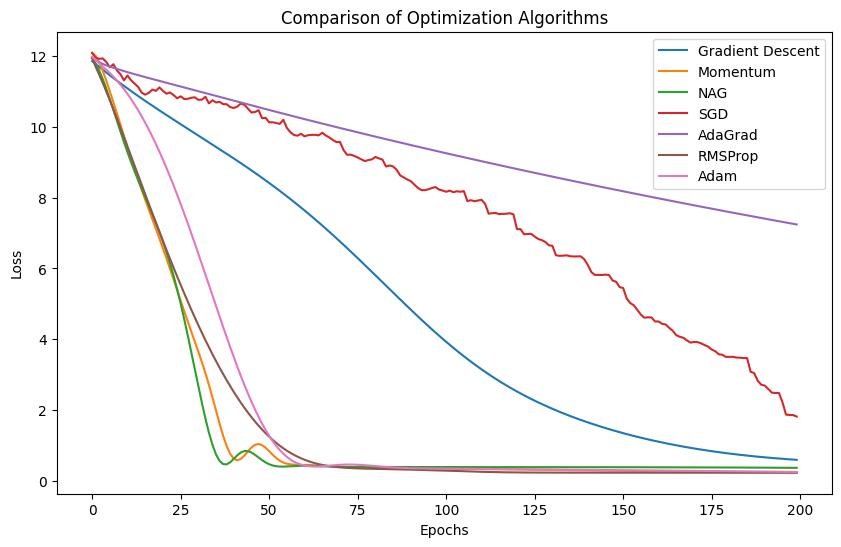

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(loss_gd, label="Gradient Descent")
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_nag, label="NAG")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_adagrad, label="AdaGrad")
plt.plot(loss_rmsprop, label="RMSProp")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparison of Optimization Algorithms")
plt.legend()
plt.show()


## DIGITS Data set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
digits = load_digits()
X = digits.data
y = digits.target


In [ ]:
# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
num_classes = 10
y_onehot = np.eye(num_classes)[y]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)


In [ ]:
def gd_update(params, grads, lr):
    for k in params:
        params[k] -= lr * grads[k]
    return params


In [ ]:
def momentum_update(params, grads, velocity, lr=0.01, beta=0.9):
    for k in params:
        velocity[k] = beta * velocity[k] - lr * grads[k]
        params[k] += velocity[k]
    return params, velocity


In [ ]:
def nesterov_update(params, grads, velocity, lr=0.01, beta=0.9):
    for k in params:
        v_prev = velocity[k]
        velocity[k] = beta * velocity[k] - lr * grads[k]
        params[k] += -beta * v_prev + (1 + beta) * velocity[k]
    return params, velocity


In [ ]:
def nesterov_update(params, grads, velocity, lr=0.01, beta=0.9):
    for k in params:
        v_prev = velocity[k]
        velocity[k] = beta * velocity[k] - lr * grads[k]
        params[k] += -beta * v_prev + (1 + beta) * velocity[k]
    return params, velocity


In [ ]:
def sgd_update(params, grads, lr):
    for k in params:
        params[k] -= lr * grads[k]
    return params


In [ ]:
def adagrad_update(params, grads, cache, lr=0.01, eps=1e-8):
    for k in params:
        cache[k] += grads[k] ** 2
        params[k] -= lr * grads[k] / (np.sqrt(cache[k]) + eps)
    return params, cache


In [ ]:
def rmsprop_update(params, grads, cache, lr=0.01, beta=0.9, eps=1e-8):
    for k in params:
        cache[k] = beta * cache[k] + (1 - beta) * grads[k] ** 2
        params[k] -= lr * grads[k] / (np.sqrt(cache[k]) + eps)
    return params, cache


In [ ]:
def adam_update(params, grads, m, v, t, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
    for k in params:
        m[k] = b1 * m[k] + (1 - b1) * grads[k]
        v[k] = b2 * v[k] + (1 - b2) * (grads[k] ** 2)

        m_hat = m[k] / (1 - b1 ** t)
        v_hat = v[k] / (1 - b2 ** t)

        params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return params, m, v


In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [ ]:
def cross_entropy(y_true, y_pred):
    eps = 1e-8
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))


In [ ]:
def init_params():
    return {
        "W1": np.random.randn(64, 64) * 0.01,
        "b1": np.zeros((1, 64)),
        "W2": np.random.randn(64, 10) * 0.01,
        "b2": np.zeros((1, 10))
    }


In [ ]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = softmax(Z2)
    return Z1, A1, A2


In [ ]:
def backward(X, y, Z1, A1, A2, params):
    m = X.shape[0]

    dZ2 = (A2 - y) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


optimizers functions written  in previous heading ( toy dataset )

In [ ]:
def train_digits(optimizer, epochs=100, lr=0.01):
    params = init_params()
    losses = []

    velocity = {k: np.zeros_like(v) for k, v in params.items()}
    cache = {k: np.zeros_like(v) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}

    for t in range(1, epochs + 1):
        Z1, A1, A2 = forward(X_train, params)
        losses.append(cross_entropy(y_train, A2))

        grads = backward(X_train, y_train, Z1, A1, A2, params)

        if optimizer == "gd":
            params = gd_update(params, grads, lr)

        elif optimizer == "momentum":
            params, velocity = momentum_update(params, grads, velocity, lr)

        elif optimizer == "nag":
            params, velocity = nesterov_update(params, grads, velocity, lr)

        elif optimizer == "adagrad":
            params, cache = adagrad_update(params, grads, cache, lr)

        elif optimizer == "rmsprop":
            params, cache = rmsprop_update(params, grads, cache, lr)

        elif optimizer == "adam":
            params, m, v = adam_update(params, grads, m, v, t, lr)

    return losses


In [ ]:
def train_digits(optimizer, epochs=100, lr=0.01):
    params = init_params()
    losses = []

    velocity = {k: np.zeros_like(v) for k, v in params.items()}
    cache = {k: np.zeros_like(v) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}

    for t in range(1, epochs + 1):
        Z1, A1, A2 = forward(X_train, params)
        losses.append(cross_entropy(y_train, A2))

        grads = backward(X_train, y_train, Z1, A1, A2, params)

        if optimizer == "gd":
            params = gd_update(params, grads, lr)

        elif optimizer == "momentum":
            params, velocity = momentum_update(params, grads, velocity, lr)

        elif optimizer == "nag":
            params, velocity = nesterov_update(params, grads, velocity, lr)

        elif optimizer == "adagrad":
            params, cache = adagrad_update(params, grads, cache, lr)

        elif optimizer == "rmsprop":
            params, cache = rmsprop_update(params, grads, cache, lr)

        elif optimizer == "adam":
            params, m, v = adam_update(params, grads, m, v, t, lr)

    return losses


In [ ]:
epochs = 900

loss_gd = train_digits("gd", epochs)
loss_momentum = train_digits("momentum", epochs)
loss_nag = train_digits("nag", epochs)
loss_adagrad = train_digits("adagrad", epochs)
loss_rmsprop = train_digits("rmsprop", epochs)
loss_adam = train_digits("adam", epochs)


## PLOT

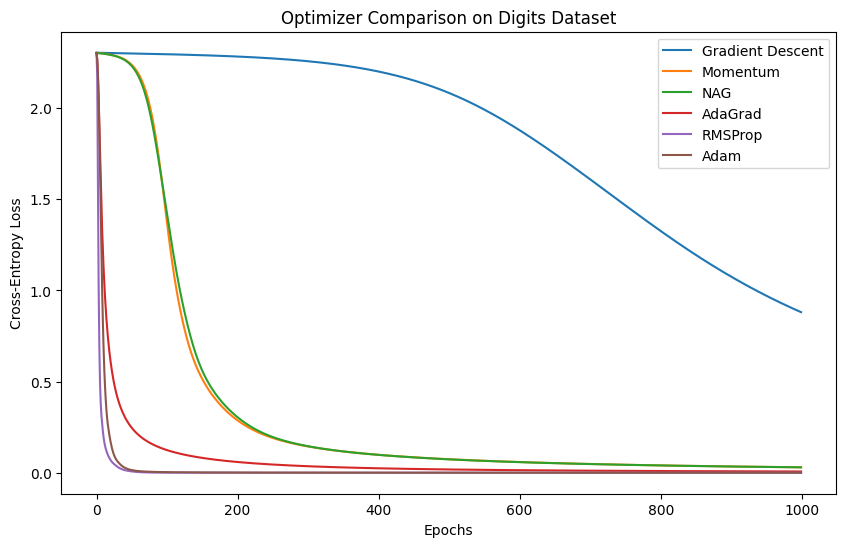

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(loss_gd, label="Gradient Descent")
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_nag, label="NAG")
plt.plot(loss_adagrad, label="AdaGrad")
plt.plot(loss_rmsprop, label="RMSProp")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Optimizer Comparison on Digits Dataset")
plt.legend()
plt.show()


## Observations

**Gradient Descent**  
Converges slowly due to fixed learning rate and absence of momentum.

**Momentum Gradient Descent**  
Accelerates convergence by accumulating past gradients and reducing oscillations.

**Nesterov Accelerated Gradient (NAG)**  
Improves momentum by computing gradients at a lookahead position, resulting in faster and more stable convergence.

**Stochastic Gradient Descent (SGD)**  
Exhibits noisy convergence due to parameter updates using single training samples.

**AdaGrad**  
Adaptive learning rate decreases aggressively, causing slow convergence in later epochs.

**RMSProp**  
Uses exponentially weighted average of squared gradients to maintain a stable learning rate.

**Adam**  
Combines momentum and RMSProp, achieving the fastest and most stable convergence.

---

**Conclusion**  
Among all optimizers, Adam performs best in terms of convergence speed and stability.
